# Oil Price Dynamics and Volatility Analysis
## A Statistical Study of Brent and WTI Crude Oil (2000–2026)
**Author:** Chijioke Amanze  
**Date:** June 2026  
**Data Source:** U.S. Energy Information Administration (EIA) API

In [1]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Data collection and Setup
The dataset was pulled from the EIA API covering the period January 2000 to March 2026. The data was saved locally as a CSV file to avoid the expense in time of making repeated API calls during the analysis and to ensure that the data remained consistent throughout the project. The code has been commented and should be uncommented before ran. A total of 5 columns were extracted covering 3270 entries 

In [2]:
# import requests
# import pandas as pd

# API_KEY = "REN7az7yEa3WmQQtxT0ezggwhr6sagPvwZJiHjHP"
# url = "https://api.eia.gov/v2/petroleum/pri/spt/data/"

# all_data = []
# offset = 0

# while True:
#     params = {
#         "api_key": API_KEY,
#         "frequency": "monthly",
#         "data[0]": "value",
#         "start": "2000-01",
#         "end": "2026-04",
#         "sort[0][column]": "period",
#         "sort[0][direction]": "asc",
#         "offset": offset,
#         "length": 5000
#     }

#     response = requests.get(url, params=params)
#     data = response.json()
#     batch = data["response"]["data"]

#     if not batch:
#         break

#     all_data.extend(batch)
#     offset += 5000
#     print(f"Fetched {len(all_data)} rows so far...")

# df = pd.DataFrame(all_data)
# df["period"] = pd.to_datetime(df["period"])
# df["value"] = pd.to_numeric(df["value"], errors="coerce")

# # Keep only the columns you need
# df = df[["period", "product", "product-name", "value", "units"]]
# df.columns = ["period", "gradeId", "gradeName", "price", "units"]

# print(f"Total rows: {len(df)}")
# print(df.head())

In [3]:
# df.to_csv("C:\\Users\\HP\\Desktop\\oil_prices.csv",index=False)

In [4]:
df= pd.read_csv("C:\\Users\\HP\\Desktop\\oil_prices.csv")
df

,period,gradeId,gradeName,price,units
0,2000-01-01,EPCBRENT,UK Brent Crude Oil,25.510,$/BBL
1,2000-01-01,EPCWTI,WTI Crude Oil,27.260,$/BBL
2,2000-01-01,EPMRU,Conventional Regular Gasoline,0.705,$/GAL
3,2000-01-01,EPMRU,Conventional Regular Gasoline,0.695,$/GAL
4,2000-01-01,EPLLPA,Propane,0.555,$/GAL
...,...,...,...,...,...
3276,2026-04-01,EPLLPA,Propane,0.766,$/GAL
3277,2026-04-01,EPMRR,Reformulated Regular Gasoline,3.772,$/GAL
3278,2026-04-01,EPMRU,Conventional Regular Gasoline,3.240,$/GAL
3279,2026-04-01,EPMRU,Conventional Regular Gasoline,3.283,$/GAL


### Data Cleaning
The missing data was calculated using the .isnull().sum() method from the pandas library, and zero missing values were found. The period column was converted from text to datetime data type to make parsing easier.

In [5]:
# check for missing values
df.isnull().sum()
# convertdate to datetime
df["period"]= pd.to_datetime(df["period"])
# Check Dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3281 entries, 0 to 3280
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   period     3281 non-null   datetime64[us]
 1   gradeId    3281 non-null   str           
 2   gradeName  3281 non-null   str           
 3   price      3281 non-null   float64       
 4   units      3281 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 128.3 KB


### Exploratory Data Analysis (EDA)
The plotly.express library was used to plot the line chart and the key geopolitical events were annotated on the chart. This library provides the ability to zoom in and out of sections which was useful for examining specific periods closely.

The correlation of the prices across all grades was determined using the seaborn heatmap. The output shows that all the grades had a strong correlation with each other except propane which was the outlier.

The Brent-WTI spread was plotted using the plotly.express library to display the price difference between the two benchmarks over the 2000–2026 period.

The same library was used to show the 12 month rolling volatility, which captures how volatile prices were over any given 12 month window, and the year on year percentage change to show the momentum of price movements over the course of each year.

The seaborn library was used yet again to show the price distribution of WTI and Brent. This was to check if the prices followed a normal distribution, which was important because non-normal distribution would affect the choice of model assumptions.

The statsmodels library was used to display the decomposition chart, helping to isolate the underlying trend once seasonality and residual noise had been stripped away.

In [23]:
import plotly.express as px



# Define key geopolitical events
events = [
    {"date": "2001-09-11", "label": "9/11"},
    {"date": "2008-09-15", "label": "2008 Financial Crisis"},
    {"date": "2011-03-01", "label": "Arab Spring"},
    {"date": "2014-11-01", "label": "OPEC Price War"},
    {"date": "2020-03-01", "label": "COVID-19 Crash"},
    {"date": "2022-02-24", "label": "Ukraine War"},
    {"date": "2026-02-28", "label": "Iran War"},
]

fig = px.line(
    df,
    x="period",
    y="price",
    color="gradeName",
    title="Crude Oil Spot Prices (2000–2026) — Key Events",
    labels={"period": "Date", "price": "Price (USD per Barrel)", "gradeName": "Grade"},
)

for event in events:
    fig.add_vline(
        x=event["date"],
        line_dash="dash",
        line_color="red",
        line_width=1,
        opacity=0.6
    )
    fig.add_annotation(
        x=event["date"],
        y=145,
        text=event["label"],
        showarrow=False,
        textangle=-45,
        font=dict(size=10, color="red"),
        yref="y"
    )

fig.update_layout(
    hovermode="x unified",
    legend_title="Oil Grade",
    template="plotly_white"
)

fig.show()

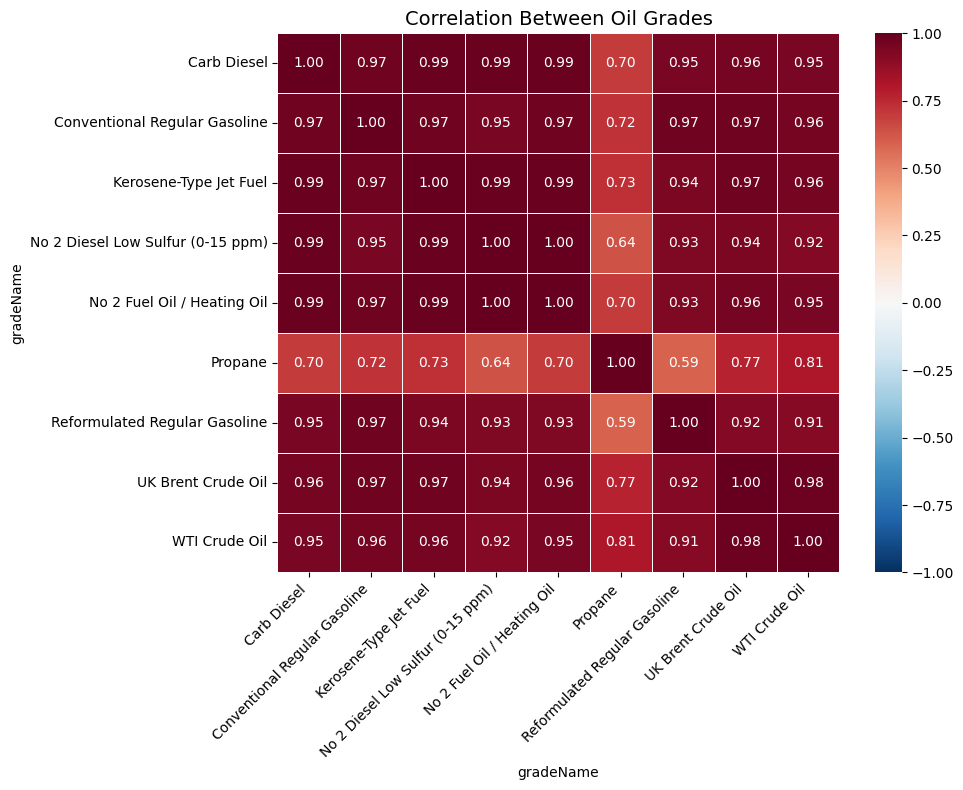

In [7]:
import seaborn as sns 
df.groupby("gradeName")["price"].describe()
# Average price per period per grade first

df_agg = df.groupby(["period", "gradeName"])["price"].mean().reset_index()

pivot = df_agg.pivot(index="period", columns="gradeName", values="price")


corr_matrix = pivot.corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white"
)

plt.title("Correlation Between Oil Grades", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [8]:
# Calculate spread
pivot["spread"] = pivot["UK Brent Crude Oil"] - pivot["WTI Crude Oil"]

# Plot
fig = px.line(
    pivot.reset_index(),
    x="period",
    y="spread",
    title="Brent-WTI Spread Over Time (2000–2026)",
    labels={"period": "Date", "spread": "Price"
    " Difference (USD per Barrel)"}
)

fig.add_hline(y=0, line_dash="dash", line_color="red", opacity=0.5)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

In [9]:


# Calculate 12-month rolling volatility for Brent and WTI
pivot["brent_volatility"] = pivot["UK Brent Crude Oil"].rolling(12).std()
pivot["wti_volatility"] = pivot["WTI Crude Oil"].rolling(12).std()

# Plot both volatilities
fig = px.line(
    pivot.reset_index(),
    x="period",
    y=["brent_volatility", "wti_volatility"],
    title="12-Month Rolling Volatility — Brent vs WTI (2000–2026)",
    labels={
        "period": "Date",
        "value": "Volatility (Std Dev, USD per Barrel)",
        "variable": "Grade"
    }
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        title="Grade",
        itemsizing="constant"
    )
)

# Rename legend labels
newnames = {"brent_volatility": "UK Brent Crude Oil", "wti_volatility": "WTI Crude Oil"}
fig.for_each_trace(lambda t: t.update(name=newnames[t.name]))

fig.show()

In [10]:
import plotly.express as px

# Calculate YoY % change for Brent and WTI
pivot["brent_yoy"] = pivot["UK Brent Crude Oil"].pct_change(12) * 100
pivot["wti_yoy"] = pivot["WTI Crude Oil"].pct_change(12) * 100

# Plot
fig = px.line(
    pivot.reset_index(),
    x="period",
    y=["brent_yoy", "wti_yoy"],
    title="Year-over-Year % Change — Brent vs WTI (2000–2026)",
    labels={
        "period": "Date",
        "value": "YoY % Change",
        "variable": "Grade"
    }
)

# Add a zero reference line
fig.add_hline(y=0, line_dash="dash", line_color="red", opacity=0.5)

# Add COVID-19 annotation
fig.add_vline(
    x="2021-02-01",
    line_color="black",
    line_width=1.5,
    opacity=0.7
)
fig.add_annotation(
    x=0.87, y=1.15,
    xref="paper", yref="paper",
    text="🔴 Geopolitical<br>🟢 Reopening<br>🔵 Supply Shock",
    showarrow=False,
    font=dict(size=12),
    align="left",
    bordercolor="black",
    borderwidth=1
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

# Rename legend labels
newnames = {"brent_yoy": "UK Brent Crude Oil", "wti_yoy": "WTI Crude Oil"}
fig.for_each_trace(lambda t: t.update(name=newnames[t.name]))

fig.show()

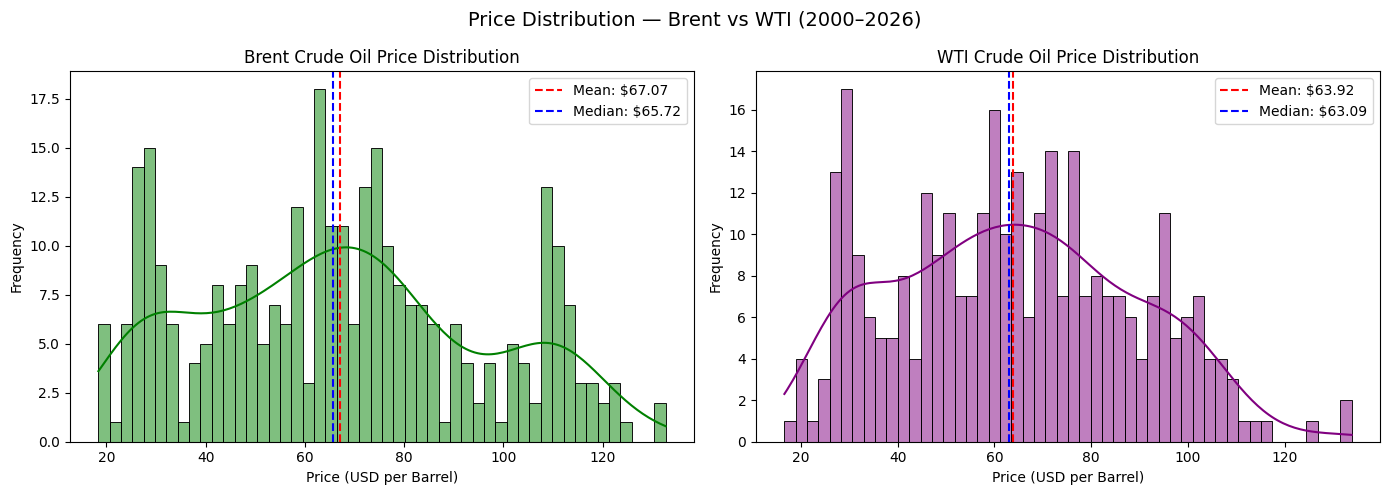

In [11]:
# Filter for just Brent and WTI
brent = df_agg[df_agg["gradeName"] == "UK Brent Crude Oil"]["price"]
wti = df_agg[df_agg["gradeName"] == "WTI Crude Oil"]["price"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Brent distribution
sns.histplot(brent, bins=50, kde=True, color="green", ax=axes[0])
axes[0].set_title("Brent Crude Oil Price Distribution")
axes[0].set_xlabel("Price (USD per Barrel)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(brent.mean(), color="red", linestyle="--", label=f"Mean: ${brent.mean():.2f}")
axes[0].axvline(brent.median(), color="blue", linestyle="--", label=f"Median: ${brent.median():.2f}")
axes[0].legend()

# WTI distribution
sns.histplot(wti, bins=50, kde=True, color="purple", ax=axes[1])
axes[1].set_title("WTI Crude Oil Price Distribution")
axes[1].set_xlabel("Price (USD per Barrel)")
axes[1].set_ylabel("Frequency")
axes[1].axvline(wti.mean(), color="red", linestyle="--", label=f"Mean: ${wti.mean():.2f}")
axes[1].axvline(wti.median(), color="blue", linestyle="--", label=f"Median: ${wti.median():.2f}")
axes[1].legend()

plt.suptitle("Price Distribution — Brent vs WTI (2000–2026)", fontsize=14)
plt.tight_layout()
plt.show()

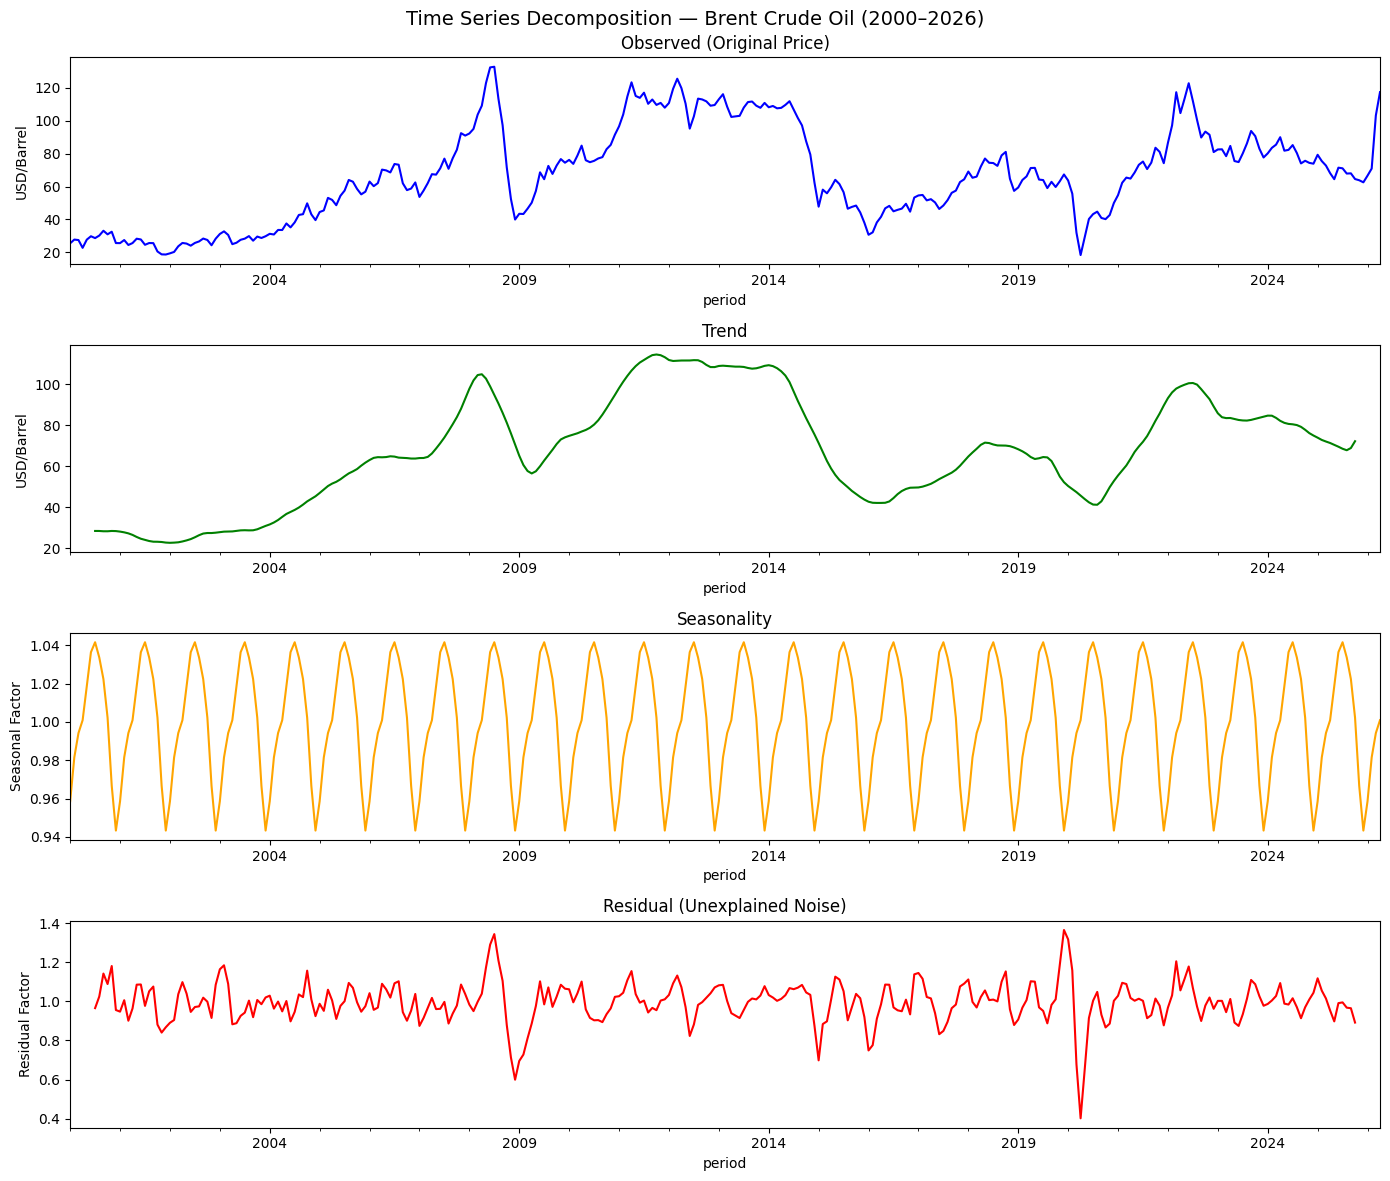

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Use Brent for decomposition - fill any missing values first
brent_series = pivot["UK Brent Crude Oil"].dropna()

# Decompose into trend, seasonality and residual
decomposition = seasonal_decompose(
    brent_series,
    model="multiplicative",  # multiplicative works better for oil prices
    period=12                 # 12 months = 1 full seasonal cycle
)

# Plot
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

decomposition.observed.plot(ax=axes[0], color="blue")
axes[0].set_title("Observed (Original Price)")
axes[0].set_ylabel("USD/Barrel")

decomposition.trend.plot(ax=axes[1], color="green")
axes[1].set_title("Trend")
axes[1].set_ylabel("USD/Barrel")

decomposition.seasonal.plot(ax=axes[2], color="orange")
axes[2].set_title("Seasonality")
axes[2].set_ylabel("Seasonal Factor")

decomposition.resid.plot(ax=axes[3], color="red")
axes[3].set_title("Residual (Unexplained Noise)")
axes[3].set_ylabel("Residual Factor")

plt.suptitle("Time Series Decomposition — Brent Crude Oil (2000–2026)", fontsize=14)
plt.tight_layout()
plt.show()

#### Statistical Testing
For this section, the WTI and Brent oil prices were used since they both are relevant to this project. 
The ADF test was carried to determine if the time series is stationary using 5% significant level. This showed that the WTI trend was stationary while the Brent oil trend was not. 
The Brent oil series was then differenced to make it stationary. 
The ACF and PACF plots were generated to determine the Moving average and autoregressive parameters (p,q and d) for the ARIMA model. 
The ACF plot revealed that the WTI series showed a slowly decaying pattern beyond the confidence bands, which is a sign of non-stationarity despite passing the ADF test.
The ARIMA diagnostic tests revealed heteroskedasticity in the residuals which meant that the ARIMA model was not sufficient.
The GARCH, GJR-GARCH and EGARCH models were therefore used as more appropriate alternatives.


In [13]:
# Augmented Dickey–Fuller (ADF) test to determine if the time series is stationary 
from statsmodels.tsa.stattools import adfuller


def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\n{'='*40}")
    print(f"ADF Test — {name}")
    print(f"{'='*40}")
    print(f"ADF Statistic:  {result[0]:.4f}")
    print(f"p-value:        {result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] <= 0.05:
        print(f"\n✅ STATIONARY — p-value {result[1]:.4f} is below 0.05")
    else:
        print(f"\n❌ NON-STATIONARY — p-value {result[1]:.4f} is above 0.05")

# Test both Brent and WTI
adf_test(pivot["UK Brent Crude Oil"], "Brent Crude Oil")
adf_test(pivot["WTI Crude Oil"], "WTI Crude Oil")



ADF Test — Brent Crude Oil
ADF Statistic:  -2.6153
p-value:        0.0899
Critical Values:
   1%: -3.4513
   5%: -2.8708
   10%: -2.5717

❌ NON-STATIONARY — p-value 0.0899 is above 0.05

ADF Test — WTI Crude Oil
ADF Statistic:  -2.9767
p-value:        0.0371
Critical Values:
   1%: -3.4513
   5%: -2.8708
   10%: -2.5717

✅ STATIONARY — p-value 0.0371 is below 0.05


In [14]:
# Difference Brent and retest
pivot["brent_diff"] = pivot["UK Brent Crude Oil"].diff()
adf_test(pivot["brent_diff"].dropna(), "Brent Crude Oil (Differenced)")


ADF Test — Brent Crude Oil (Differenced)
ADF Statistic:  -12.4875
p-value:        0.0000
Critical Values:
   1%: -3.4513
   5%: -2.8708
   10%: -2.5717

✅ STATIONARY — p-value 0.0000 is below 0.05


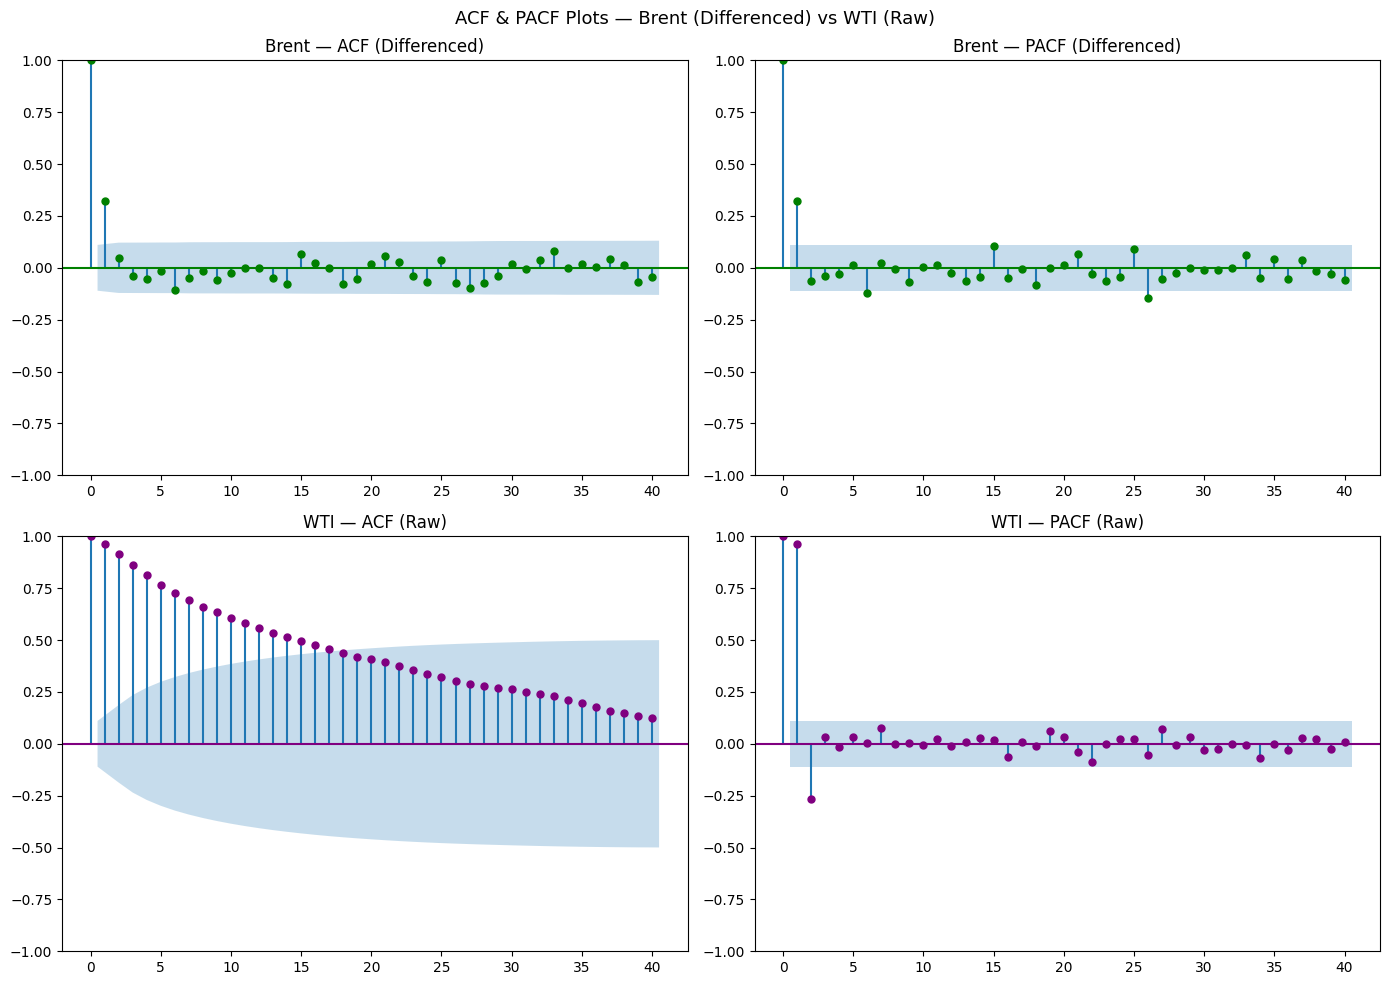

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Use differenced Brent and raw WTI
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Brent ACF
plot_acf(pivot["brent_diff"].dropna(), lags=40, ax=axes[0, 0], color="green")
axes[0, 0].set_title("Brent — ACF (Differenced)")

# Brent PACF
plot_pacf(pivot["brent_diff"].dropna(), lags=40, ax=axes[0, 1], color="green")
axes[0, 1].set_title("Brent — PACF (Differenced)")

# WTI ACF
plot_acf(pivot["WTI Crude Oil"].dropna(), lags=40, ax=axes[1, 0], color="purple")
axes[1, 0].set_title("WTI — ACF (Raw)")

# WTI PACF
plot_pacf(pivot["WTI Crude Oil"].dropna(), lags=40, ax=axes[1, 1], color="purple")
axes[1, 1].set_title("WTI — PACF (Raw)")

plt.suptitle("ACF & PACF Plots — Brent (Differenced) vs WTI (Raw)", fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# WTI also showed non-stationarity from ACF — differencing to confirm
pivot["wti_diff"] = pivot["WTI Crude Oil"].diff()
adf_test(pivot["wti_diff"].dropna(), "WTI Crude Oil (Differenced)")


ADF Test — WTI Crude Oil (Differenced)
ADF Statistic:  -12.3254
p-value:        0.0000
Critical Values:
   1%: -3.4513
   5%: -2.8708
   10%: -2.5717

✅ STATIONARY — p-value 0.0000 is below 0.05


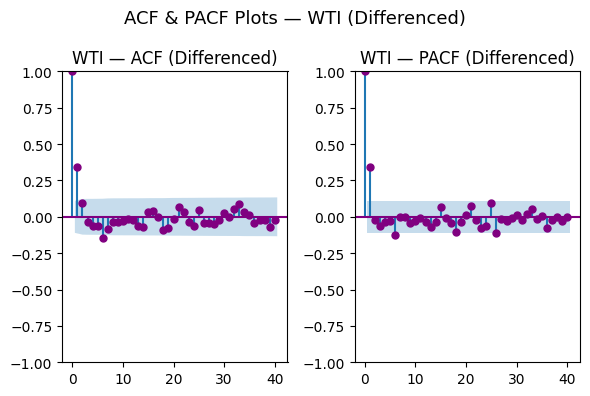

In [17]:
# WTI ACF
fig, axes = plt.subplots(1,2, figsize=(6, 4))
plot_acf(pivot["wti_diff"].dropna(), lags=40, ax=axes[0], color="purple")
axes[0].set_title("WTI — ACF (Differenced)")

# WTI PACF
plot_pacf(pivot["wti_diff"].dropna(), lags=40, ax=axes[1], color="purple")
axes[1].set_title("WTI — PACF (Differenced)")

plt.suptitle("ACF & PACF Plots — WTI (Differenced)", fontsize=13)
plt.tight_layout()
plt.show()

#### ARIMA 
This model was chosen because both the WTI and Brent oil series were stationary after differencing once. The ACF and PACF plots suggested ARIMA(1,1,1) parameters where p=1 representing the autoregressive term, d=1 representing one round of differencing and q=1 representing the moving average term 

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:     UK Brent Crude Oil   No. Observations:                  316
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1008.051
Date:                Fri, 12 Jun 2026   AIC                           2022.102
Time:                        21:35:37   BIC                           2033.360
Sample:                    01-01-2000   HQIC                          2026.600
                         - 04-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2085      0.119      1.747      0.081      -0.025       0.442
ma.L1          0.1310      0.135      0.968      0.333      -0.134       0.396
sigma2        35.2366      1.783     19.765      0.0

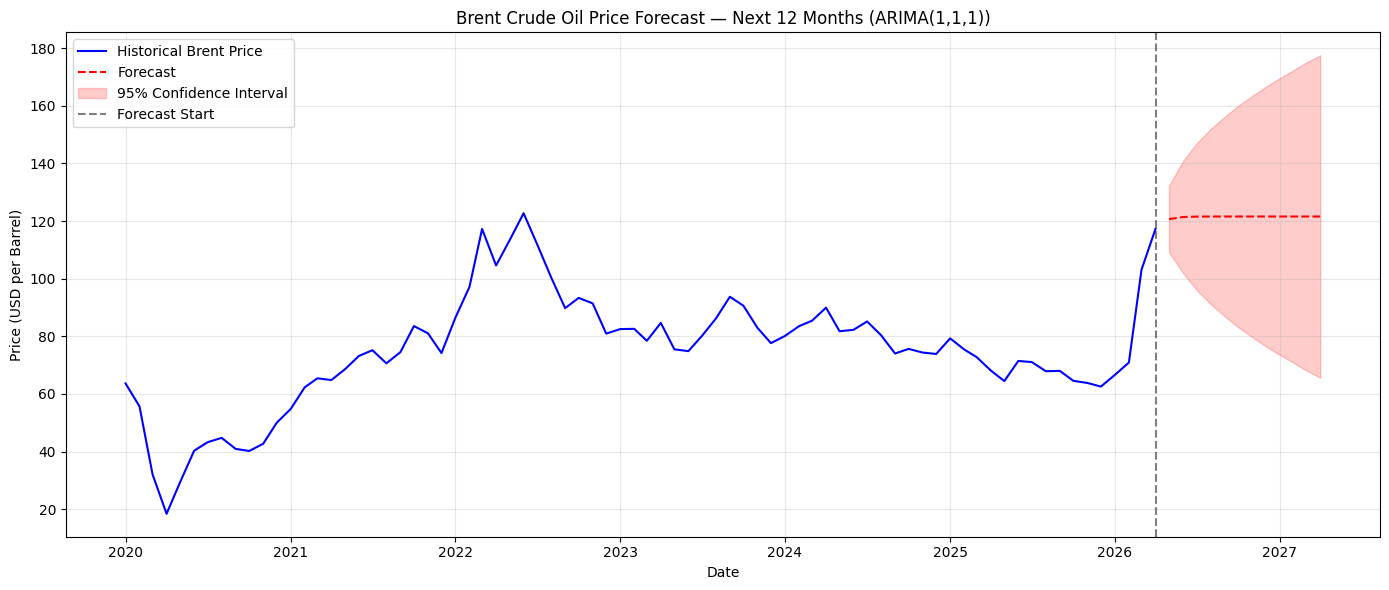

In [18]:
# ARIMA MODEL
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA

# Ensure index is datetime
brent_series = pivot["UK Brent Crude Oil"].dropna()
brent_series.index = pd.to_datetime(brent_series.index)

model = ARIMA(brent_series, order=(1, 1, 1))
fitted_model = model.fit()
print(fitted_model.summary())

forecast = fitted_model.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

last_date = brent_series.index[-1]
future_dates = pd.date_range(start=last_date, periods=13, freq="MS")[1:]
forecast_mean.index = future_dates
forecast_ci.index = future_dates

fig, ax = plt.subplots(figsize=(14, 6))

# Plot using .values to avoid index conversion issues
ax.plot(brent_series["2020":].index, brent_series["2020":].values, 
        color="blue", label="Historical Brent Price")
ax.plot(future_dates, forecast_mean.values, 
        color="red", label="Forecast", linestyle="--")
ax.fill_between(
    future_dates,
    forecast_ci.iloc[:, 0].values,
    forecast_ci.iloc[:, 1].values,
    color="red", alpha=0.2, label="95% Confidence Interval"
)
ax.axvline(x=last_date, color="black", linestyle="--", alpha=0.5, label="Forecast Start")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Brent Crude Oil Price Forecast — Next 12 Months (ARIMA(1,1,1))")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD per Barrel)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### GARCH Model
Three GARCH variants were fitted to model the volatility of Brent crude oil returns. The standard GARCH(1,1) established a baseline showing strong shock sensitivity (alpha = 0.4252) but failed to capture volatility persistence with beta = 0.000. GJR-GARCH improved on this by revealing that negative shocks generate 7.6X more volatility than positive shocks (gamma = 0.5673, p = 0.004), confirming a strong asymmetric response to bad news in oil markets. EGARCH was fitted as a final comparison and was the only model to correctly identify volatility persistence, revealing that 75% of each month's volatility carries forward into the next (beta = 0.75). EGARCH is recommended as the preferred model overall while GJR-GARCH remains valuable for its asymmetry finding.

In [19]:
# GARCH MODELS

from arch import arch_model

brent_returns = pivot["UK Brent Crude Oil"].pct_change().dropna() * 100

# Standard GARCH(1,1)
model_garch = arch_model(
    brent_returns, vol="Garch", p=1, q=1,
    mean="AR", lags=1, dist="t"
)
fitted_garch = model_garch.fit(disp="off")
print(fitted_garch.summary())



                              AR - GARCH Model Results                              
Dep. Variable:           UK Brent Crude Oil   R-squared:                       0.036
Mean Model:                              AR   Adj. R-squared:                  0.033
Vol Model:                            GARCH   Log-Likelihood:               -1127.09
Distribution:      Standardized Student's t   AIC:                           2266.17
Method:                  Maximum Likelihood   BIC:                           2288.67
                                              No. Observations:                  314
Date:                      Fri, Jun 12 2026   Df Residuals:                      312
Time:                              21:35:38   Df Model:                            2
                                  Mean Model                                 
                    coef    std err          t      P>|t|    95.0% Conf. Int.
-----------------------------------------------------------------------------
C

In [20]:
# GJR-GARCH
model_gjr = arch_model(
    brent_returns, vol="GARCH", p=1, o=1, q=1,
    mean="AR", lags=1, dist="t"
)
fitted_gjr = model_gjr.fit(disp="off")
print(fitted_gjr.summary())

                            AR - GJR-GARCH Model Results                            
Dep. Variable:           UK Brent Crude Oil   R-squared:                       0.043
Mean Model:                              AR   Adj. R-squared:                  0.039
Vol Model:                        GJR-GARCH   Log-Likelihood:               -1122.62
Distribution:      Standardized Student's t   AIC:                           2259.24
Method:                  Maximum Likelihood   BIC:                           2285.48
                                              No. Observations:                  314
Date:                      Fri, Jun 12 2026   Df Residuals:                      312
Time:                              21:35:38   Df Model:                            2
                                  Mean Model                                 
                    coef    std err          t      P>|t|    95.0% Conf. Int.
-----------------------------------------------------------------------------
C

In [21]:
# EGARCH
model_egarch = arch_model(
    brent_returns, vol="EGARCH", p=1, q=1,
    mean="AR", lags=1, dist="t"
)
fitted_egarch = model_egarch.fit(disp="off")
print(fitted_egarch.summary())

                             AR - EGARCH Model Results                              
Dep. Variable:           UK Brent Crude Oil   R-squared:                       0.041
Mean Model:                              AR   Adj. R-squared:                  0.038
Vol Model:                           EGARCH   Log-Likelihood:               -1126.02
Distribution:      Standardized Student's t   AIC:                           2264.03
Method:                  Maximum Likelihood   BIC:                           2286.53
                                              No. Observations:                  314
Date:                      Fri, Jun 12 2026   Df Residuals:                      312
Time:                              21:35:38   Df Model:                            2
                                  Mean Model                                  
                    coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------------------------------------------------------------

The conditional volatility of each of the three models was plotted to compare how each model estimated market uncertainty over the 2000–2026 period. Key geopolitical events were annotated to show how each model responded to major market shocks. Comparing the three models visually helps identify which model most accurately captured the volatility behaviour of oil prices, especially around key crisis periods such as the 2008 financial crisis, the 2014 OPEC price war and the 2020 COVID crash.

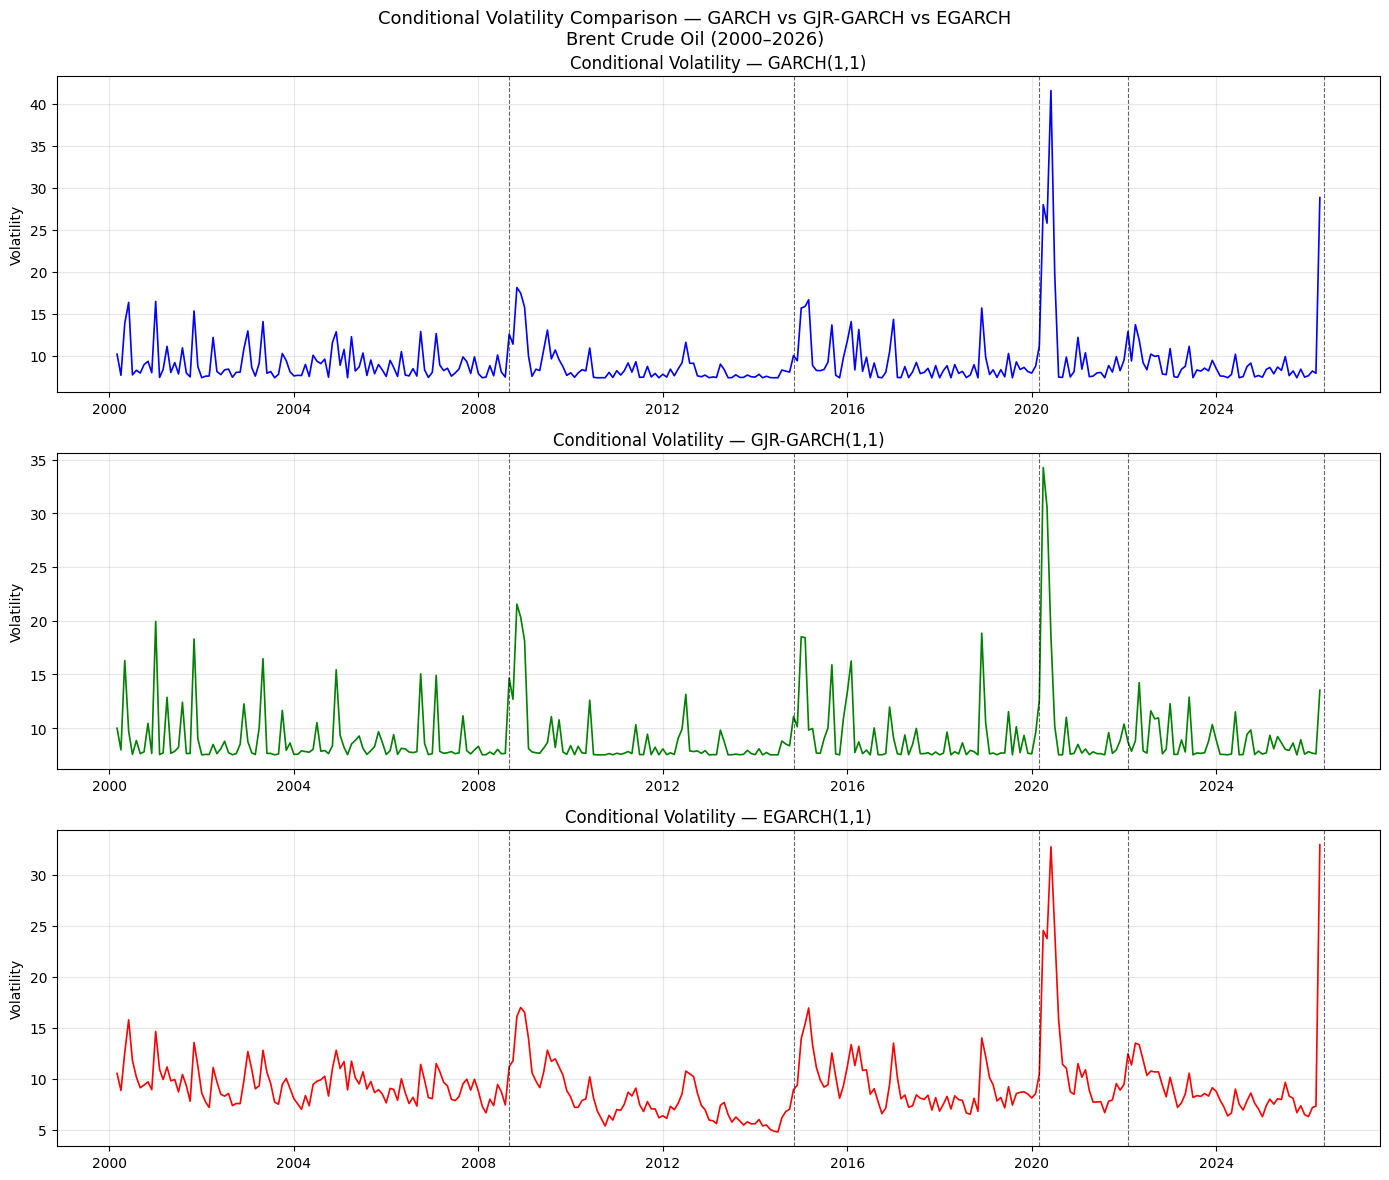

In [22]:
# Conditional volatility comparison plot

import matplotlib.dates as mdates

garch_vol = fitted_garch.conditional_volatility
gjr_vol = fitted_gjr.conditional_volatility
egarch_vol = fitted_egarch.conditional_volatility

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

events = [
    {"date": "2008-09-01", "label": "2008 Financial Crisis"},
    {"date": "2014-11-01", "label": "OPEC Price War"},
    {"date": "2020-03-01", "label": "COVID-19 Crash"},
    {"date": "2022-02-01", "label": "Ukraine War"},
    {"date": "2026-05-01", "label": "UAE Exits OPEC"},
]

for ax, vol, title, color in zip(
    axes,
    [garch_vol, gjr_vol, egarch_vol],
    ["GARCH(1,1)", "GJR-GARCH(1,1)", "EGARCH(1,1)"],
    ["blue", "green", "red"]
):
    # Convert index to datetime explicitly
    vol.index = pd.to_datetime(vol.index)
    
    ax.plot(vol.index, vol.values, color=color, linewidth=1.2)
    ax.set_title(f"Conditional Volatility — {title}")
    ax.set_ylabel("Volatility")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    for event in events:
        event_date = pd.Timestamp(event["date"])
        ax.axvline(x=event_date, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.text(
            event_date, vol.values.max() * 0.85, event["label"],
            rotation=90, fontsize=8, color="black", alpha=0.8, va="top"
        )

plt.suptitle(
    "Conditional Volatility Comparison — GARCH vs GJR-GARCH vs EGARCH\nBrent Crude Oil (2000–2026)",
    fontsize=13
)
plt.tight_layout()
plt.show()